In [1]:
import Pkg
Pkg.activate(".")
#Pkg.instantiate()

  Activating project at `~/Documents/programming/SigmaCampNext-2025`


In [ ]:
Pkg.add("Catalyst")
Pkg.add("OrdinaryDiffEqTsit5")
Pkg.add("Plots")
Pkg.add("Optimization")
Pkg.add("SciMLSensitivity")
Pkg.add("OptimizationOptimJL")
Pkg.add("Optim")

In [2]:
using Catalyst, OrdinaryDiffEqTsit5, Plots

In [3]:
t=default_t()
@parameters k_on switch_time k_off
@species A(t) B(t)

rxs = [(@reaction k_on, A--> B), (@reaction k_off, B-->A)]

2-element Vector{Reaction{Any, Int64}}:
 k_on, A --> B
 k_off, B --> A

In [4]:
discrete_events = (t == switch_time) => [k_on ~ 0.0]

u0 = [:A => 10.0, :B => 0.0]
tspan = (0.0, 4.0)
p = [k_on => 100.0, switch_time => 2.0, k_off => 10.0]

3-element Vector{Pair{Num, Float64}}:
        k_on => 100.0
 switch_time => 2.0
       k_off => 10.0

In [5]:
@named osys = ReactionSystem(rxs, t, [A, B], [k_on, k_off, switch_time]; discrete_events)
osys = complete(osys)

oprob = ODEProblem(osys, u0, tspan, p)
sol = solve(oprob, Tsit5(); tstops = 2.0)

retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 105-element Vector{Float64}:
 0.0
 9.999000050004998e-7
 1.0998900055005497e-5
 0.00011098890055505546
 0.0007570567404369951
 0.0022249154214992036
 0.004390001422588812
 0.007140471256485504
 0.010622255936105232
 0.014751593689173406
 0.019550535489083063
 0.024970422414049454
 0.031039523905385117
 ⋮
 2.7208807003809596
 2.8003768086767398
 2.881757156194859
 2.9656216780270475
 3.0532547501064764
 3.146742142432296
 3.2488808233338484
 3.363171433429317
 3.4941191900007773
 3.6479365191555844
 3.833749337719228
 4.0
u: 105-element Vector{Vector{Float64}}:
 [10.0, 0.0]
 [9.999000154981985, 0.0009998450180154056]
 [9.989007750931561, 0.01099224906843915]
 [9.889685870094032, 0.11031412990596748]
 [9.273608574602152, 0.7263914253978488]
 [8.026432035586408, 1.9735679644135928]
 [6.518103969091188, 3.481896030908813]
 [5.053761036622382, 4.946238963377619]
 [3.7349923945949604, 6.2650076054050405]
 [2.703367

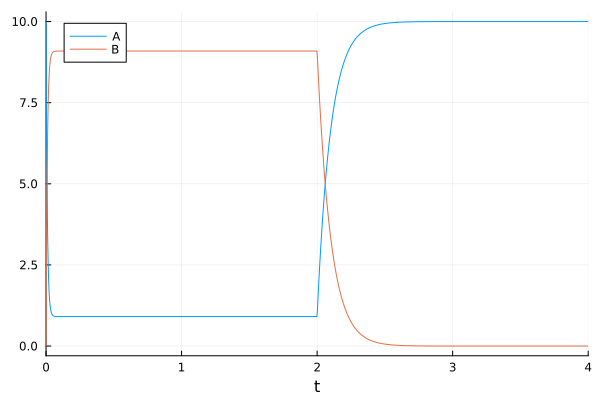

In [6]:
plot(sol)

In [15]:
using ModelingToolkit, Optimization, SciMLSensitivity, OptimizationOptimJL, Optim

In [8]:
@variables t 
@parameters k_on k_off α
@species A(t) B(t)

rxs = [(@reaction α*k_on, A-->B), (@reaction k_off, B-->A)]

switch_time = 2.0
discrete_events = (t == switch_time) => [k_on ~ 0.0]

tspan = (0.0, 4.0)

alpha_list = [0.1, 0.2, 0.3, 0.4]
results_list = []

Any[]

In [9]:
u0 = [:A => 10.0, :B => 0.0]
p_real = [k_on => 100.0, k_off => 10.0, α => 1.0]
@named osys = ReactionSystem(rxs, t, [A, B], [k_on, k_off, α]; discrete_events)
osys = complete(osys)
oprob = ODEProblem(osys, u0, tspan, p_real)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Initialization status: FULLY_DETERMINED
Non-trivial mass matrix: false
timespan: (0.0, 4.0)
u0: 2-element Vector{Float64}:
 10.0
  0.0

In [10]:
sample_times = range(tspan[1]; stop = tspan[2], length = 1001) 

for alpha in alpha_list
    p_real = [k_on => 100.0, k_off => 10.0, α => alpha]
    oprobr = remake(oprob, p=p_real)
    sol_real = solve(oprobr, Tsit5(); tstops = sample_times)

    push!(results_list, sol_real(sample_times))
end

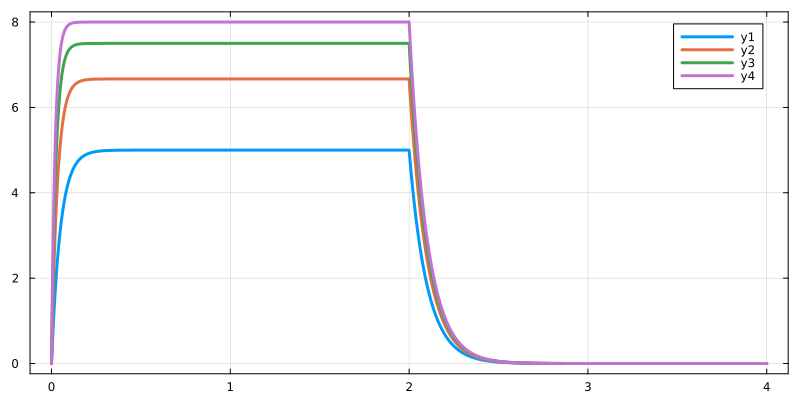

In [11]:
default(; lw = 3, framestyle = :box, size = (800, 400))
plot(sample_times, results_list[1][2,:])
plot!(sample_times, results_list[2][2,:])
plot!(sample_times, results_list[3][2,:])
plot!(sample_times, results_list[4][2,:])

In [12]:
sample_vals = []
for result in results_list
    sample_val = Array(result)
    sample_val .*= (1 .+ .1 * rand(Float64, size(sample_val)) .- .05)
    push!(sample_vals, sample_val)
end

In [13]:
for val in sample_vals
    scatter!(sample_times, sample_vals; color = [:blue :red], legend = nothing)
end

function optimise_p(pinit, tend)
    function loss(p, _)
        newtimes = filter(<=(tend), sample_times)
        solutions = []
        for alpha in alpha_list
            newprob = remake(oprob; tspan = (0.0, tend), p = [k_on => p[1],k_off => p[2],α => alpha])
            sol = Array(solve(newprob, Tsit5(); saveat = newtimes, tstops = switch_time))
            push!(solutions,sol[2,:])
        end
        loss = 0
        for (idx, solution) in enumerate(solutions)
            loss += sum(abs2, p[3]*solution .- sample_vals[idx][1:size(sol,2)])
        end

        return loss
    end
    optf = OptimizationFunction(loss)
    
    optprob = OptimizationProblem(optf, pinit)
    sol = solve(optprob, Optim.NelderMead())

    return sol.u
end


optimise_p (generic function with 1 method)

In [16]:
p_estimate = optimise_p([100.0, 10.0, 1.0], 1.5)

3-element Vector{Float64}:
 1118.7746541970414
   -0.1462149863828089
    0.49954329094347305

In [17]:
alpha = 0.2
newprob = remake(oprob; tspan = (0.0, 4.0), p = [k_on => p_estimate[1], k_off => p_estimate[2], α => alpha])
newsol = solve(newprob, Tsit5(); tstops = switch_time)

retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 156-element Vector{Float64}:
 0.0
 4.468728359412738e-7
 4.915601195354012e-6
 4.960288478948139e-5
 0.0003543178325039068
 0.0010625352765054232
 0.0021166026310398094
 0.0034512282602203676
 0.005138290295217892
 0.007122994626430833
 0.00940259148368082
 0.01192831136223305
 0.014674926667852462
 ⋮
 1.9324797277392585
 1.948162689974875
 1.9638456520909617
 1.9795286151632858
 1.9952115779965507
 2.0
 2.0
 2.0121112528558593
 2.133223781414452
 2.7361800118171344
 3.978877635697536
 4.0
u: 156-element Vector{Vector{Float64}}:
 [10.0, 0.0]
 [9.99900014995067, 0.0009998500493299338]
 [9.989007142568308, 0.010992857431691386]
 [9.889624354335718, 0.1103756456642818]
 [9.237789467090984, 0.7622105329090153]
 [7.883859458095503, 2.1161405419044965]
 [6.227023573909815, 3.772976426090185]
 [4.618635918445185, 5.381364081554814]
 [3.1651774552307526, 6.8348225447692466]
 [2.0284232202839867, 7.971576779716012]
 [

In [18]:

plot(sol_real; legend = nothing, color = [:darkblue :darkred])
scatter!(sample_times, sample_vals; color = [:darkblue :darkred], legend = nothing)

default(; lw = 3, framestyle = :box, size = (800, 400))
#plot the sample noise and also index and add the t timespan
plot!(newsol[2,:]; legend = nothing, color = [:blue :red], linestyle = :dash, tspan= (0.0, 4.0))

LoadError: UndefVarError: `sol_real` not defined in `Main`
Suggestion: check for spelling errors or missing imports.